# Intro to Quaternions

Quaternions can be described as hyper-complex numbers of rank 4:

$$
    q = q_0 + \mathbf{q}
$$

Made up of a scalar part ($q$) and a vector part ($\mathbf{q}$).

Alternatively, this can be written as:

$$
    q = q_0 + q_1 i + q_2 j + q_3 k
$$

Because quaternions are the sum of a scalar and a vector, they do not obey the typical rules of linear algebra.

## Addition

$$
p = p_0 + i p_1 + j p_2 + k p_3, \qquad q = q_0 + i q_1 + j q_2 + k q_3
$$
$$
p + q = (p_0 + q_0) + i(p_1+q_1) + j(p_2+q_2) + k(p_3+q_3)
$$

## Scalar Multiplication

$$
cp = c p_0 + i c p_1 + j c p_2 + k c p_3
$$

## Special Products

\begin{align*}
i^2 = j^2 = k^2 = ijk &= -1 \\
ij = k &= -ji \\
jk = i &= -kj \\
ki = j &= -ik
\end{align*}

## Quaternion Product

$$
pq = p_0 q_0 - \mathbf{p}\cdot\mathbf{q} + p_0 \mathbf{q} + q_0 \mathbf{p} + \mathbf{p}\times\mathbf{q}
$$

## Matrix Representation

Alternatively, a quaternion product can be written as a matrix product:
$$
pq = r = r_0 + \mathbf{r} = r_0 + i r_1 + j r_2 + k r_3
$$

$$
\begin{bmatrix} r_0 \\ r_1 \\ r_2 \\ r_3 \end{bmatrix}
=
\begin{bmatrix}
p_0 & -p_1 & -p_2 & -p_3 \\
p_1 & p_0 & -p_3 & p_2 \\
p_2 & p_3 & p_0 & -p_1 \\
p_3 & -p_2 & p_1 & p_0
\end{bmatrix}
\begin{bmatrix} q_0 \\ q_1 \\ q_2 \\ q_3 \end{bmatrix}
$$

Since the cross product is not commutative, neither is the quaternion product.

## Complex Conjugate

$$
q = q_0 + \mathbf{q}, \qquad q^* = q_0 - \mathbf{q}
$$
$$
(pq)^* = q^* p^*
$$
$$
q + q^* = (q_0 + \mathbf{q}) + (q_0 - \mathbf{q}) = 2q_0
$$

## Quaternion Operators

$$
L_q(\mathbf{v}) = \mathbf{w} = q\mathbf{v}q^*
 = (q_0^2 - |\mathbf{q}|^2)\mathbf{v} + 2(\mathbf{q}\cdot\mathbf{v})\mathbf{q} + 2q_0(\mathbf{q}\times\mathbf{v})
$$

operated on vector $\mathbf{v}$ in $\mathbb{R}^3$.

### Properties:

1. Linear Operator: $L_q(k\mathbf{a} + \mathbf{b}) = k L_q(\mathbf{a}) + L_q(\mathbf{b})$
2. Norm: $|L_q(\mathbf{v})| = |\mathbf{v}|$
    - note: $|x| = \sqrt{x^*x}$

$$
L_q(\mathbf{v}) = \mathbf{w} = q^*\mathbf{v}q = (2q_0^2 - 1)\mathbf{v} + 2(\mathbf{v}\cdot\mathbf{q})\mathbf{q} - 2q_0(\mathbf{v}\times\mathbf{q})
$$


Luckily, TOAST has already made a bunch of useful quaternion algebra functions. 

In [20]:
# First let's add the toast module
from pathlib import Path

HOME = Path("/shared_home/henachman")
toast_git = HOME / 'toast'
toast_src = toast_git / 'src' / 'toast'

# add the toast src to path
import sys
if str(toast_src) not in sys.path:
    sys.path.append(str(toast_src))
    sys.path.append(str(toast_src.parent))

print(sys.path)
from qarray import *

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.style.use('/shared_home/henachman/.matplotlib/stylelib/HNCustomMono.mplstyle')

['/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python313.zip', '/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13', '/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/lib-dynload', '', '/shared_home/software/soconda_builds/soconda_20260813_0.2.5/lib/python3.13/site-packages', '/shared_home/henachman/toast/src/toast', '/shared_home/henachman/toast/src']


A simple case of a single rotation about the z axis

In [21]:
def plot_quaternion(q, axis, **kwargs):
    q_axis = to_axisangle(q)[0]
    axis.quiver(0,0,0, q_axis[0], q_axis[1], q_axis[2], **kwargs)

def plot_vect(vect, axis, **kwargs):
    axis.quiver(0,0,0, vect[0], vect[1], vect[2], **kwargs)

def rad_to_deg(rad):
    return rad*180/np.pi

Note: the toast code defines a quaternion as:
$$
q = \text{np.array}([i, j, k, s])
$$
where $s$ is the standard scalar part of the quaternion.


(-1.0, 1.0)

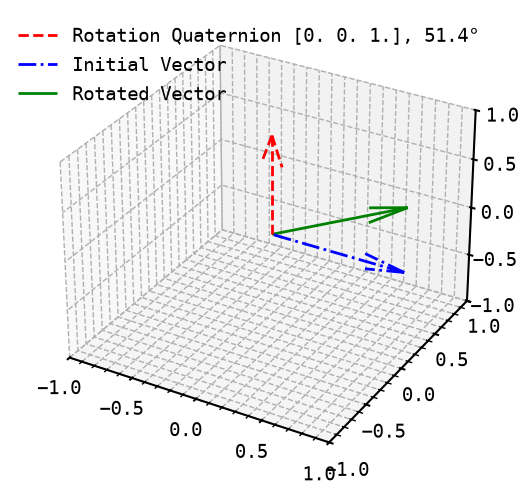

In [22]:
# Define a quaternion

alpha = np.pi/3.5

q = np.array([0.0, 0.0, np.sin(alpha/2), np.cos(alpha/2)])

fig3 = plt.figure(figsize=(10, 6))

ax3d   = fig3.add_subplot(projection="3d")

vect = np.array([1.0, 0.0, 0.0])

q_axis, q_angle = to_axisangle(q)
plot_quaternion(q, ax3d, color="red", linestyle='--', label=f"Rotation Quaternion {q_axis}, {round(rad_to_deg(q_angle), 1)}°")
plot_vect(vect, ax3d, color="blue", linestyle='-.', label = 'Initial Vector')

# rotate the vector with the quaternion
vect_prime = rotate(q, vect)

plot_vect(vect_prime, ax3d, color = 'g', label = 'Rotated Vector')

ax3d.legend()

ax3d.set_xlim(-1, 1)
ax3d.set_ylim(-1, 1)
ax3d.set_zlim(-1, 1)

Let's add a rotation. 

Imagine we want to rotate first about the z-axis, then about the new y-axis. In normal rotation matrix world, we would need to multiple these rotation matrices. With quaternions, we can multiply the quaternions.

3.7416573867739413


(-1.0, 1.0)

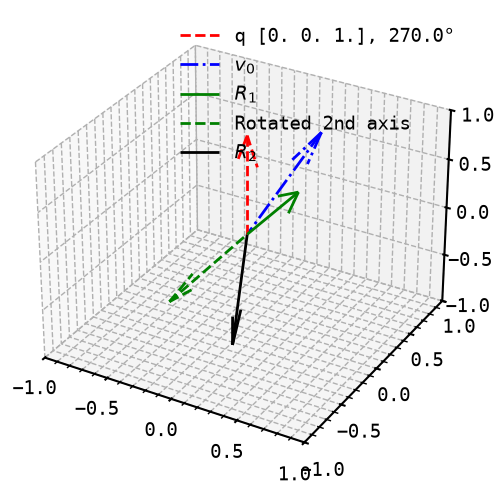

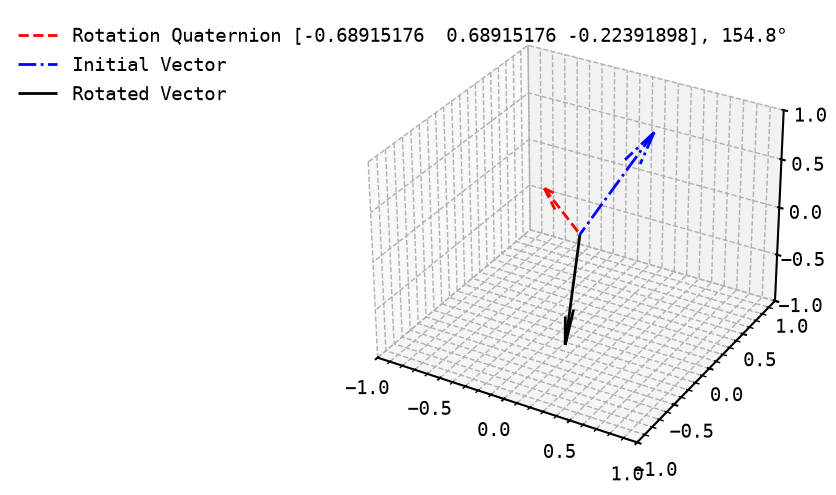

In [23]:
# Define a quaternion

alpha = np.pi/2 * 3
beta = np.pi/5 * 6

q = np.array([0.0, 0.0, np.sin(alpha/2), np.cos(alpha/2)])
p = np.array([np.sin(beta/2), 0.0, 0.0, np.cos(beta/2)])

vect = np.array([1.0, 2.0, 3.0])

def vector_norm(vect):
    return np.sqrt(np.sum(vect**2))

vect_norm = vector_norm(vect)
print(vect_norm)
vect = vect/vect_norm
# Let's first see how these rotation look individually

fig3 = plt.figure(figsize=(10, 6))

ax3d   = fig3.add_subplot(projection="3d")

q_axis, q_angle = to_axisangle(q)
plot_quaternion(q, ax3d, color="red", linestyle='--', label=f"q {q_axis}, {round(rad_to_deg(q_angle), 1)}°")
plot_vect(vect, ax3d, color="blue", linestyle='-.', label = r'$v_0$')
# rotate the vector with the quaternion
vect_prime = rotate(q, vect)
plot_vect(vect_prime, ax3d, color = 'g', label = r'$R_1$')

# Now let's plot the new y axis 
# to do this I have to compute what the new y axis is
y_axis, _ = to_axisangle(p)
new_y_axis = rotate(q, y_axis)
plot_vect(new_y_axis, ax3d, color = 'g', label = r'Rotated 2nd axis', linestyle="--")

# Now we rotate about the new axis
# Note I cheated here and used the product of the two original quaternions
# If you are not convinced yet that doing this is equivalent it might be worth
# working out an example by hand.
qp = mult(q, p)
vect_final = rotate(qp, vect)
plot_vect(vect_final, ax3d, color = 'black', label = r'$R_2$')

ax3d.legend()

ax3d.set_xlim(-1, 1)
ax3d.set_ylim(-1, 1)
ax3d.set_zlim(-1, 1)



# alternatively we can do this in fewer steps by simply multiplying the quaternions


fig3 = plt.figure(figsize=(10, 6))
ax3d   = fig3.add_subplot(projection="3d")
qp_axis, qp_angle = to_axisangle(qp)
plot_quaternion(qp, ax3d, color="red", linestyle='--', label=f"Rotation Quaternion {qp_axis}, {round(rad_to_deg(qp_angle), 1)}°")
plot_vect(vect, ax3d, color="blue", linestyle='-.', label = 'Initial Vector')

# rotate the vector with the quaternion
vect_prime = rotate(qp, vect)

plot_vect(vect_prime, ax3d, color = 'black', label = 'Rotated Vector')

ax3d.legend()

ax3d.set_xlim(-1, 1)
ax3d.set_ylim(-1, 1)
ax3d.set_zlim(-1, 1)

2.465989797109545


(-1.0, 1.0)

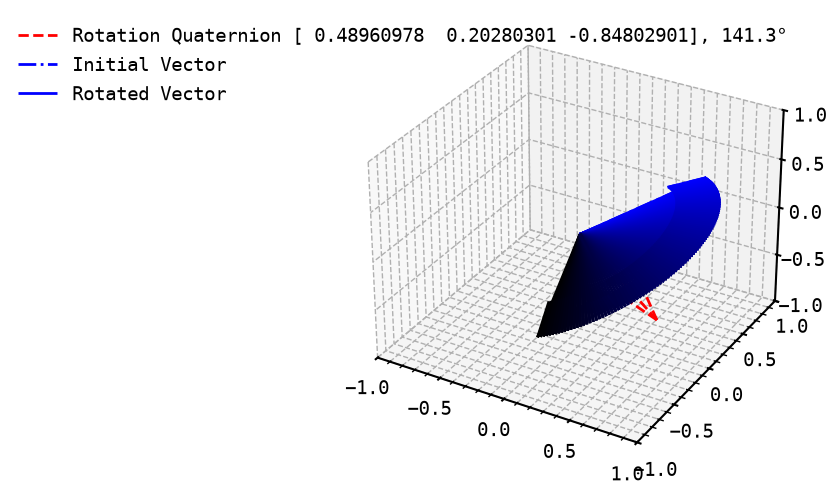

In [32]:
# Define a quaternion

# Define the combined rotation
alpha = np.pi / 4 * 3
beta = np.pi / 3

q = np.array([0.0, 0.0, -np.sin(alpha/2), np.cos(alpha/2)])
p = np.array([0.0, np.sin(beta/2), 0.0, np.cos(beta/2)])
qp = mult(q, p)
# This is the final quaternion
qp_axis, qp_angle = to_axisangle(qp)
print(qp_angle)
angle_range = np.linspace(0, qp_angle, 100)

fig3 = plt.figure(figsize=(10, 6))
ax3d   = fig3.add_subplot(projection="3d")

vect = np.array([2.0, 3.0, 1.0])
vect_norm = vector_norm(vect)
vect = vect/vect_norm

plot_quaternion(qp, ax3d, color="red", linestyle='--', label=f"Rotation Quaternion {qp_axis}, {round(rad_to_deg(qp_angle), 1)}°")
plot_vect(vect, ax3d, color="blue", linestyle='-.', label = 'Initial Vector')


for i, angle in enumerate(angle_range):
    new_q = from_axisangle(qp_axis, angle)
    # print(to_axisangle(new_q))
    # rotate the vector with the quaternion
    vect_prime = rotate(new_q, vect)
    # print(vect_prime)

    # Interpolate from blue at angle=0 to black at the final angle
    color = (0.0, 0.0, 1.0 - angle / qp_angle)
    plot_vect(
        vect_prime,
        ax3d,
        color=color,
        label='Rotated Vector' if i == 0 else None
    )

ax3d.legend()

ax3d.set_xlim(-1, 1)
ax3d.set_ylim(-1, 1)
ax3d.set_zlim(-1, 1)

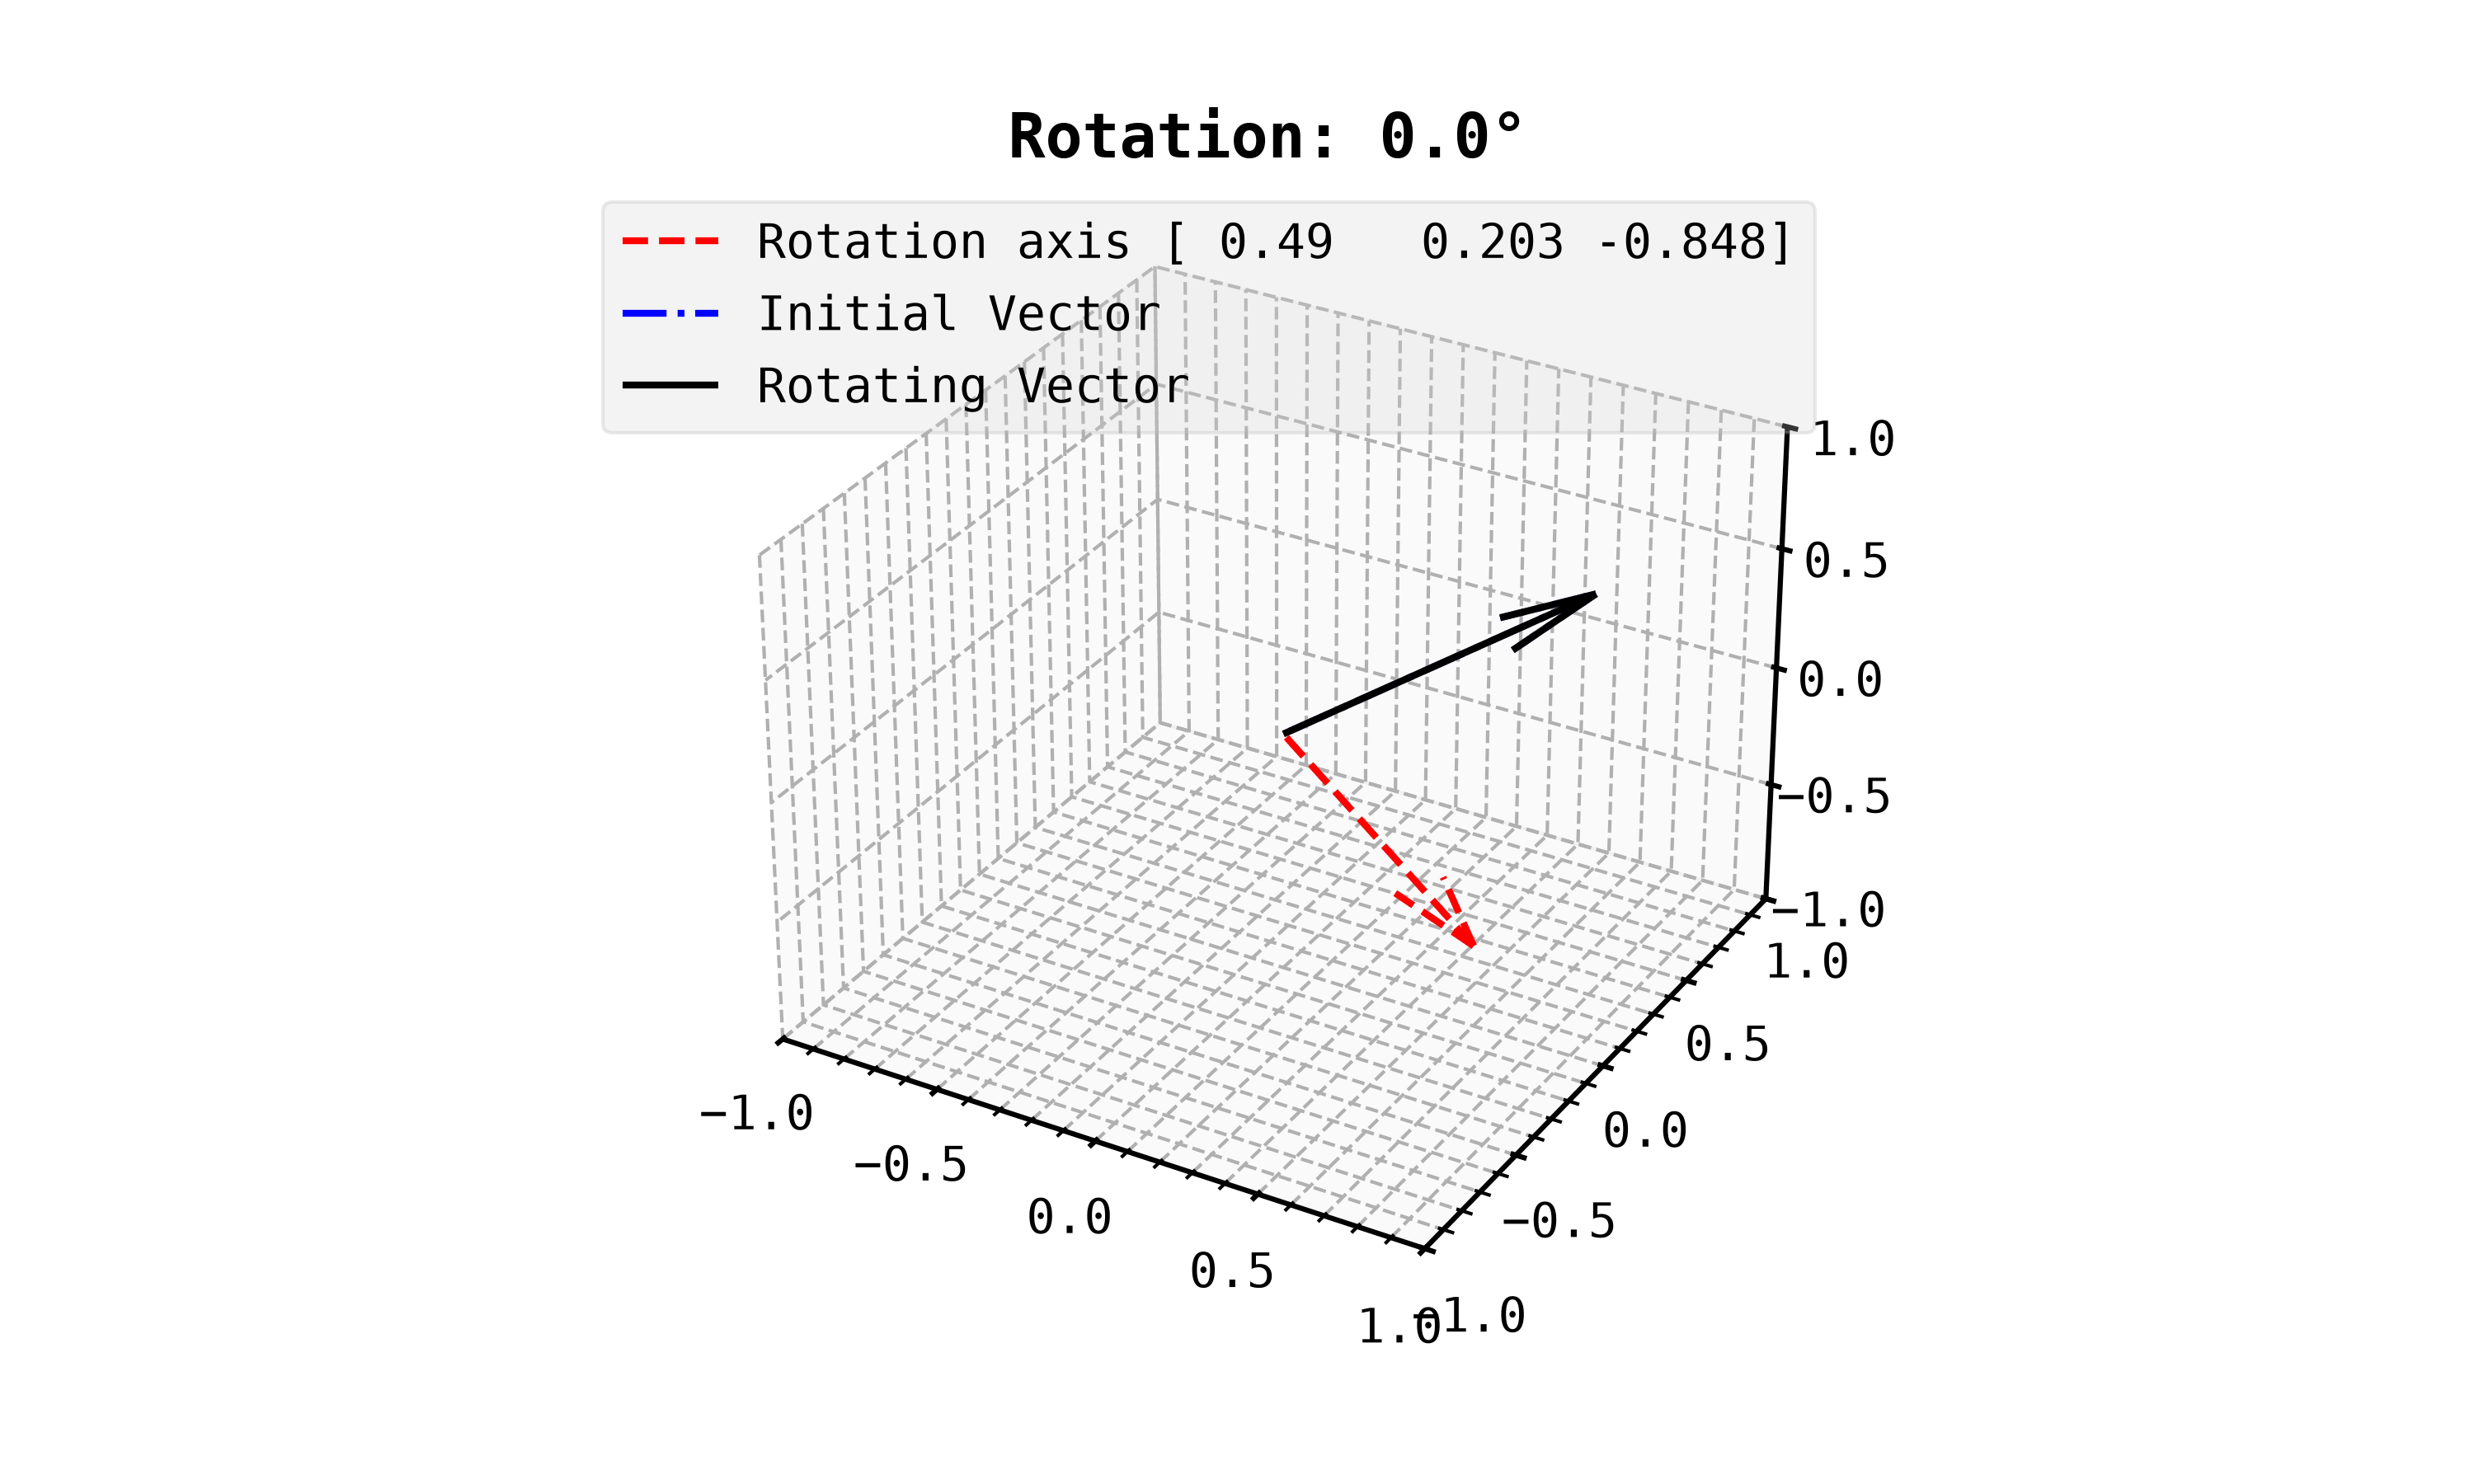

In [47]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# Define the combined rotation
alpha = np.pi / 4 * 3
beta = np.pi / 3

q = np.array([0.0, 0.0, -np.sin(alpha/2), np.cos(alpha/2)])
p = np.array([0.0, np.sin(beta/2), 0.0, np.cos(beta/2)])
qp = mult(q, p)

qp_axis, qp_angle = to_axisangle(qp)
angle_range = np.linspace(0, qp_angle, 100)
angle_range = np.append(angle_range, [qp_angle]*15)

vect = np.array([2.0, 3.0, 1.0])
vect /= vector_norm(vect)

rotated_vectors = np.array([
    rotate(from_axisangle(qp_axis, angle), vect)
    for angle in angle_range
])

fig3 = plt.figure(figsize=(10, 6))
ax3d = fig3.add_subplot(projection="3d")

def update(frame):
    ax3d.clear()

    current_vect = rotated_vectors[frame]

    plot_quaternion(
        qp, ax3d, color="red", linestyle="--",
        label=f"Rotation axis {np.round(qp_axis,3)}"
    )
    plot_vect(vect, ax3d, color="blue", linestyle="-.", label="Initial Vector")

    # Faint trail of the rotation
    for previous_vect in rotated_vectors[:frame + 1]:
        plot_vect(previous_vect, ax3d, color="lightblue", alpha=0.25)

    plot_vect(
        current_vect, ax3d, color="black",
        linewidth=2, label="Rotating Vector"
    )

    ax3d.xaxis.set_pane_color((0.0, 0.0, 0.0, 0.02))
    ax3d.yaxis.set_pane_color((0.0, 0.0, 0.0, 0.02))
    ax3d.zaxis.set_pane_color((0.0, 0.0, 0.0, 0.02))
    ax3d.set_xlim(-1, 1)
    ax3d.set_ylim(-1, 1)
    ax3d.set_zlim(-1, 1)
    ax3d.set_title(
        f"Rotation: {rad_to_deg(angle_range[frame]):.1f}°"
    )
    legend = ax3d.legend(frameon=True)
    lframe = legend.get_frame()
    lframe.set_facecolor('lightgray')
    lframe.set_alpha(0.25)

animation = FuncAnimation(
    fig3, update, frames=len(angle_range),
    interval=50, blit=False
)

gif_path = "quaternion_rotation.gif"
animation.save(gif_path, writer=PillowWriter(fps=20))
plt.close(fig3)

display(Image(filename=gif_path))